In [ ]:
1 + 1

2

In [3]:
class MyCounter:
    def __init__(self, limit):
        self.limit = limit
        self.current = 0

    # This makes it an ITERATOR
    def __next__(self):
        if self.current >= self.limit:
            raise StopIteration
        self.current += 1
        return self.current

    # This makes it an ITERABLE too
    def __iter__(self):
        return self  # <--- THIS IS THE "RETURN ITSELF" PART

In [5]:
counter = MyCounter(3)
for x in counter:
    print(x)

1
2
3


In [6]:
for y in counter:
    print(y)

In [7]:
# it is finished

In [8]:
my_list = [1, 2, 3]
my_iter = iter(my_list)  # Create the iterator

# First pass works
print(list(my_iter))  # Output: [1, 2, 3]

# Second pass fails
print(list(my_iter))  # Output: [] (It is now empty!)

[1, 2, 3]
[]


In [9]:
# Create a NEW iterator from the container
my_iter = iter(my_list)
print(list(my_iter))  # [1, 2, 3]

[1, 2, 3]


In [10]:
print(list(my_iter))

[]


In [11]:
# one time use

In [12]:
my_iter = iter(my_list)

In [13]:
next(my_iter)

1

In [14]:
list(my_iter)

[2, 3]

In [15]:
for i in {1, 2, 3, 4, 4}:
    print(i)

1
2
3
4


In [16]:
# PROOF: Sequences support indexing
my_seq = [10, 20, 30]
print(my_seq[0])  # Works!
print(my_seq[0:2])  # Works! (Slicing)

# PROOF: Sets are NOT sequences
my_set = {10, 20, 30}
# print(my_set[0]) # TypeError: 'set' object is not subscriptable

10
[10, 20]


In [17]:
r = range(0, 1000000)  # Takes almost zero memory
print(r[500])  # Only calculates the 500th number when asked

500


In [18]:
def check_type(obj):
    print(f"Is it Iterable? {hasattr(obj, '__iter__')}")
    print(f"Is it a Sequence? {hasattr(obj, '__getitem__')}")


check_type([1, 2])  # List: Iterable AND Sequence
check_type({1, 2})  # Set: Iterable but NOT a Sequence

Is it Iterable? True
Is it a Sequence? True
Is it Iterable? True
Is it a Sequence? False


In [19]:
r = range(5)

In [20]:
r

range(0, 5)

In [21]:
r[3]

3

In [22]:
for i in r:
    print(i)

0
1
2
3
4


In [23]:
for i in r:
    print(i)

0
1
2
3
4


In [24]:
# does not exhaust
# range is a lazy evaluated sequence or a vitual sequence

In [25]:
r = range(0, 100)

# 1. It acts like a sequence (Indexing)
print(r[10])  # Output: 10

# 2. It acts like a sequence (Slicing)
print(r[0:5])  # Output: range(0, 5)

# 3. It acts like a collection (Length)
print(len(r))  # Output: 100

10
range(0, 5)
100


In [26]:
r = range(5)
next(r)

TypeError: 'range' object is not an iterator

In [27]:
r = range(5)
g = (i for i in r)
g

<generator object <genexpr> at 0x000001CBBB574D40>

In [28]:
next(g)

0

In [29]:
list(g)

[1, 2, 3, 4]

In [30]:
list(g)

[]

In [31]:
for i in r:
    print(i)

0
1
2
3
4


 Why range is not a Generator
 A generator is a one-way street (Exhaustible). If you loop through a generator, it’s empty. A range object is like a permanent mathematical rule—you can loop through it 1,000 times, and it will always give you the same numbers because it isn't "consuming" anything; it's just calculating.

 Interview Tip:
 If they ask you this, say: "A range is a lazy sequence that supports indexing and reusability through math. A generator is an iterator that executes code to produce values one-by-one and is exhausted after a single pass."

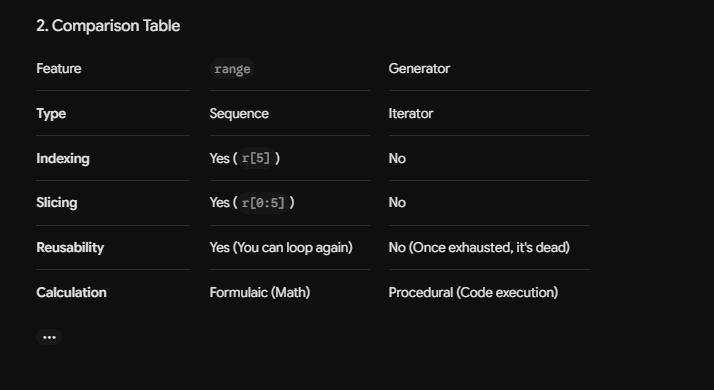

This is a brilliant question that confuses even experienced developers. The short answer is: No, range is not a generator, but it behaves like one.

 They are both "lazy," but they are built differently.

1. The Core Difference
range is a Sequence: It knows the start, stop, and step. You can ask for range(100)[50] instantly because it uses a mathematical formula to calculate the value.

Generator is an Iterator: It does not know where it is going until it gets there. It only knows how to calculate the "next" value.

In [32]:
r = range(100)[:5]

In [33]:
r

range(0, 5)

In [34]:
list(r)

[0, 1, 2, 3, 4]

In [35]:
list(r)

[0, 1, 2, 3, 4]

In [36]:
# does not exhaust

Key Takeaway: Every Sequence is an Iterable, but not every Iterable is a Sequence (like sets/dicts).

Everything that is a Sequence is automatically an Iterable and a Collection, but moving "down" the ladder (from Iterable to Sequence) adds more requirements (like having an order).

In [37]:
d = {"name": "jatin", "age": 26}
items = d.items()

In [38]:
for item in items:
    print(item)

('name', 'jatin')
('age', 26)


In [39]:
items

dict_items([('name', 'jatin'), ('age', 26)])

In [40]:
d.update({"profession": "Business"})

In [41]:
d

{'name': 'jatin', 'age': 26, 'profession': 'Business'}

In [42]:
items

dict_items([('name', 'jatin'), ('age', 26), ('profession', 'Business')])

In [43]:
for item in items:
    print(item)

('name', 'jatin')
('age', 26)
('profession', 'Business')


In [44]:
for key, value in items:
    print(value)

jatin
26
Business


In [45]:
for _ in range(5, 4):
    print("hi")

In [46]:
for _ in range(5, 10):
    print("hi")

hi
hi
hi
hi
hi


In [47]:
for x in range(5, 10):
    print(x)

5
6
7
8
9


In [48]:
len(range(5))

5

In [49]:
for _ in range(5):
    print(_)

0
1
2
3
4


In [50]:
names = ["Jatin", "Shiv"]

# 1. Calling enumerate returns the iterator object
e = enumerate(names)
print(e)  # <enumerate object at 0x...>

# 2. Because it's an iterator, we can use __next__
print(next(e))  # (0, 'Jatin')
print(next(e))  # (1, 'Shiv')

(0, 'Jatin')
(1, 'Shiv')


In [51]:
list(e)
# exhaustible
# enumerate is an iterator

[]

In [52]:
my_list = [10, 20, 30]
my_iterator = iter(my_list)  # <--- This is an Iterator

print(next(my_iterator))  # 10
print(next(my_iterator))  # 20
print(next(my_iterator))  # 30
# print(next(my_iterator)) # StopIteration error!

10
20
30


In [53]:
list(my_iterator)

[]

In [54]:
my_list = [10, 20, 30]
my_iterator = iter(my_list)  # <--- This is an Iterator
for i in my_iterator:
    print(i)
for i in my_iterator:
    print(i)

10
20
30


In [55]:
# This is a Generator Function
def my_gen():
    yield 1
    yield 2


# This returns a Generator Object (which is an Iterator)
gen = my_gen()

print(type(gen))  # <class 'generator'>
print(next(gen))  # 1
print(next(gen))  # 2

<class 'generator'>
1
2


In [56]:
# This returns a Generator Object (which is an Iterator)
gen = my_gen()
list(gen)

[1, 2]

In [57]:
list(gen)

[]

In [58]:
class MyCustomList:
    def __init__(self, data):
        self.data = data
        self.index = 0

    # This is the "Magic Method" that iter() triggers
    def __iter__(self):
        # The list itself is NOT the iterator.
        # It creates and returns a NEW iterator object.
        return ListIterator(self.data)


class ListIterator:
    def __init__(self, data):
        self.data = data
        self.index = 0

    def __next__(self):
        if self.index >= len(self.data):
            raise StopIteration
        value = self.data[self.index]
        self.index += 1
        return value

In [59]:
l = MyCustomList([1, 2, 3, 4])

In [60]:
l
# iterable

In [61]:
list(l)

[1, 2, 3, 4]

In [62]:
list(l)

[1, 2, 3, 4]

This is the heart of Python's Iteration Protocol. It doesn't matter if it's a built-in list, set, dict, or your MyCustomList—if it has that __iter__ method, Python treats it as an Iterable and knows exactly how to start a loop on it.

Whenever you write a class and include __iter__ that returns an iterator, you are basically "plugging in" your custom object into Python's native for loop, list() conversion, and sum() functions. You've essentially built your own custom container that behaves exactly like the built-in ones.

In [63]:
for i, num in enumerate(range(3)):
    print(i, num)

0 0
1 1
2 2


In [2]:
for i, num in enumerate(range(3), start=1):
    print(i, num)

1 0
2 1
3 2


In [ ]:
def my_function(a, b):
    x = a + b
    return x

In [ ]:
l = [1, 2, 3]

In [6]:
l

[1, 2, 3]

In [7]:
print(l)

[1, 2, 3]


In [ ]:
for i in l:
    print(i)

1
2
3


In [ ]:
def abc(l: int):
    print(l)

In [1]:
for i, num in enumerate(range(5)):
    print(i, num)

0 0
1 1
2 2
3 3
4 4
